In [1]:
import numpy as np
import pandas as pd 
from matplotlib import rcParams, rcParamsDefault
import matplotlib.pyplot as plt
import seaborn as sns

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}

In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## 

In [4]:
import matplotlib.patches as mpatches
seed = 1234

eid = 'E003'
data_E003 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv_para.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 
data_E003 = pd.merge(data_E003,meta[['gene_id','mean','mean_label','cv','eid']], how='inner',on='gene_id')


eid = 'E118'
data_E118 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv_para.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E118 = pd.merge(data_E118,meta[['gene_id','mean','mean_label','cv','eid']], how='inner',on='gene_id')

eid = 'E116'
data_E116 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv_para.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E116 = pd.merge(data_E116,meta[['gene_id','mean','mean_label','cv','eid']], how='inner',on='gene_id')

data = pd.concat([data_E003,data_E118,data_E116],)
data['mean'] = np.log1p(data['mean'])
data['cv'] = np.log1p(data['cv'])



fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(5/2.54, 4/2.54))

# 绘制散点图
scatter = sns.scatterplot(data=data, x='mean', y='cv', s=0.1, hue='eid', ax=ax)

ax.tick_params(axis='both', labelsize=5, width=0.5)
ax.set_xlabel("Log1p(CV)", fontsize=6, ha='center')
ax.set_ylabel("Log1p(MEAN)", fontsize=6, ha='center')
ax.legend().remove()
# 获取唯一的 eid 及对应的颜色
unique_eids = [EIDS_TO_CELLTYPES[_eid] for _eid in data['eid'].unique()]
palette = sns.color_palette(n_colors=len(unique_eids))

# 创建手动图例
handles = [mpatches.Patch(color=palette[i], label=str(unique_eids[i])) for i in range(len(unique_eids))]

# 添加到 figure 级别
fig.legend(handles=handles, loc='upper right',bbox_to_anchor=(1.1, 1.0) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure5A.eps', format='eps', bbox_inches='tight')

plt.show()

KeyError: "['mean_label'] not in index"

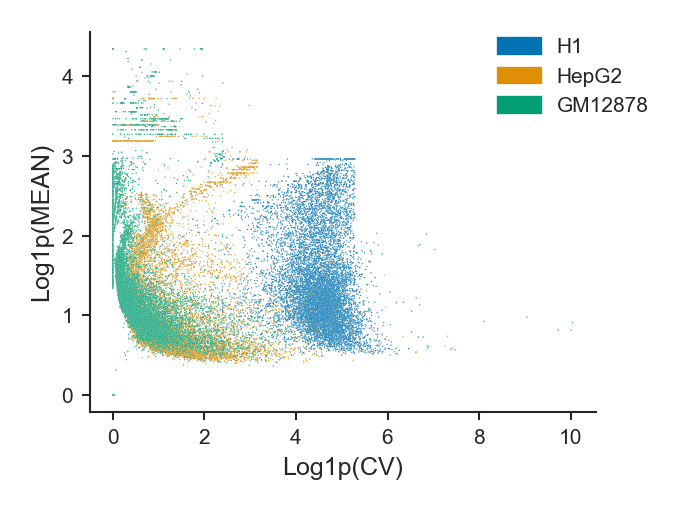

In [8]:
import matplotlib.patches as mpatches
seed = 1234

eid = 'E003'
data_E003 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 
data_E003 = pd.merge(data_E003,meta[['gene_id','bs','bs_label','cv','eid']], how='inner',on='gene_id')


eid = 'E118'
data_E118 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E118 = pd.merge(data_E118,meta[['gene_id','bs','bs_label','cv','eid']], how='inner',on='gene_id')

eid = 'E116'
data_E116 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E116 = pd.merge(data_E116,meta[['gene_id','bs','bs_label','cv','eid']], how='inner',on='gene_id')

data = pd.concat([data_E003,data_E118,data_E116],)
data['bs'] = np.log1p(data['bs'])
data['cv'] = np.log1p(data['cv'])



fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(5/2.54, 4/2.54))

# 绘制散点图
scatter = sns.scatterplot(data=data, x='bs', y='cv', s=0.1, hue='eid', ax=ax)

ax.tick_params(axis='both', labelsize=5, width=0.5)
ax.set_xlabel("Log1p(CV)", fontsize=6, ha='center')
ax.set_ylabel("Log1p(MEAN)", fontsize=6, ha='center')
ax.legend().remove()
# 获取唯一的 eid 及对应的颜色
unique_eids = [EIDS_TO_CELLTYPES[_eid] for _eid in data['eid'].unique()]
palette = sns.color_palette(n_colors=len(unique_eids))

# 创建手动图例
handles = [mpatches.Patch(color=palette[i], label=str(unique_eids[i])) for i in range(len(unique_eids))]

# 添加到 figure 级别
fig.legend(handles=handles, loc='upper right',bbox_to_anchor=(1.1, 1.0) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure5A.eps', format='eps', bbox_inches='tight')

plt.show()

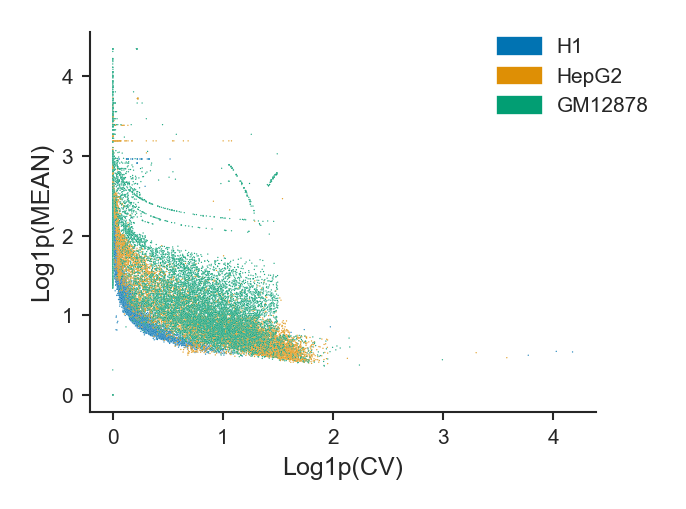

In [6]:
import matplotlib.patches as mpatches
seed = 1234

eid = 'E003'
data_E003 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 
data_E003 = pd.merge(data_E003,meta[['gene_id','bf','bf_label','cv','eid']], how='inner',on='gene_id')


eid = 'E118'
data_E118 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E118 = pd.merge(data_E118,meta[['gene_id','bf','bf_label','cv','eid']], how='inner',on='gene_id')

eid = 'E116'
data_E116 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions_cv.csv')
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"
meta = (pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True))  
data_E116 = pd.merge(data_E116,meta[['gene_id','bf','bf_label','cv','eid']], how='inner',on='gene_id')

data = pd.concat([data_E003,data_E118,data_E116],)
data['bf'] = np.log1p(data['bf'])
data['cv'] = np.log1p(data['cv'])



fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(5/2.54, 4/2.54))

# 绘制散点图
scatter = sns.scatterplot(data=data, x='bf', y='cv', s=0.1, hue='eid', ax=ax)

ax.tick_params(axis='both', labelsize=5, width=0.5)
ax.set_xlabel("Log1p(CV)", fontsize=6, ha='center')
ax.set_ylabel("Log1p(MEAN)", fontsize=6, ha='center')
ax.legend().remove()
# 获取唯一的 eid 及对应的颜色
unique_eids = [EIDS_TO_CELLTYPES[_eid] for _eid in data['eid'].unique()]
palette = sns.color_palette(n_colors=len(unique_eids))

# 创建手动图例
handles = [mpatches.Patch(color=palette[i], label=str(unique_eids[i])) for i in range(len(unique_eids))]

# 添加到 figure 级别
fig.legend(handles=handles, loc='upper right',bbox_to_anchor=(1.1, 1.0) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure5A.eps', format='eps', bbox_inches='tight')

plt.show()

## Signal Strength

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


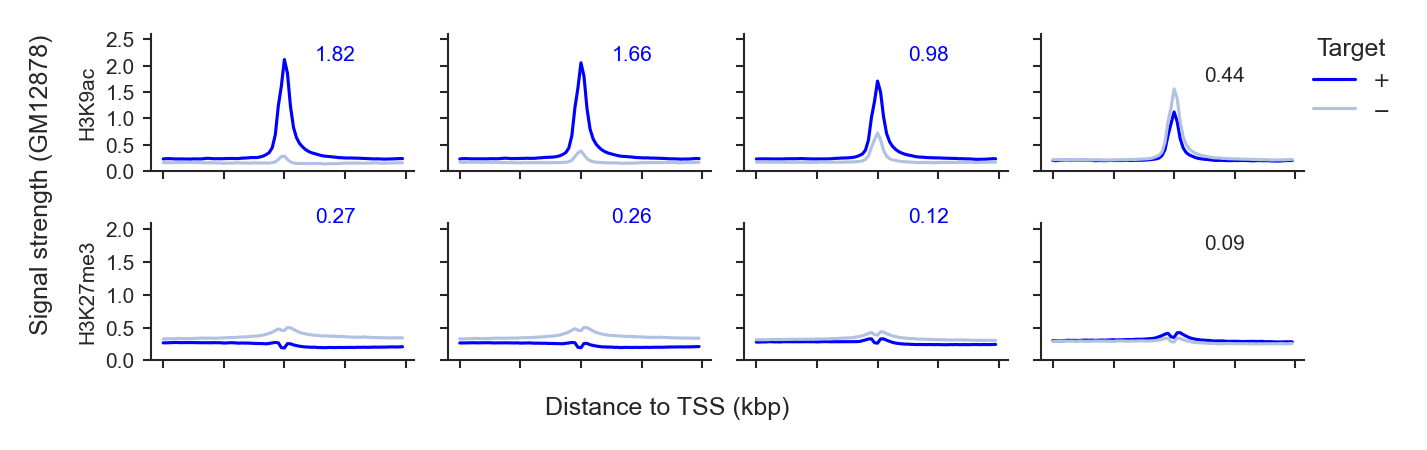

In [17]:
eid = 'E116'

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac','H3K27me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(11/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx1, mark in enumerate(yticks):
    _idx = MARKS.index(mark)

    for idx2,target in enumerate(['mean','bf','bs','cv']):
        high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_{target}_highmarks.npy")
        low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_{target}_lowmarks.npy")
        # Plot the data without 'label' argument to avoid legends in subplots
        sns.lineplot(high_marks[_idx], color='blue',  ax=ax[idx1,idx2])
        sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[idx1,idx2])
        # ax[idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
        if idx2 < 3:
            ax[idx1, idx2].text(50,2.1,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
        else:
            ax[idx1, idx2].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
        # Set the y-axis ticks
        if idx1 == 0:
            ax[idx1, idx2].set_yticks([i * 0.1 for i in range(0, 26, 5)])
        else:
            ax[idx1, idx2].set_yticks([i * 0.1 for i in range(0, 21, 5)])
        ax[idx1, idx2].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
        if idx2 == 0:
            ax[idx1, idx2].set_ylabel(mark,fontsize=5)
            ax[idx1,idx2].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
        else:
            ax[idx1,idx2].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
        # Set the title for each subplot
        # ax[idx1,idx2].set_title(mark, fontsize=6,fontweight='regular')
        if idx1 == 0:
            ax[idx1,idx2].set_ylim(ymax=2.6)
        else:
            ax[idx1,idx2].set_ylim(ymax=2.1)
        # Set the xlabel for each subplot

lines = ax[0,0].get_lines()

handles = [lines[0], lines[1]]
labels = ["$+$", "$-$"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.07, 1.0) ,title='Target', title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6,y=0.6)
# Adjust layout to ensure everything fits



plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


## Regulation

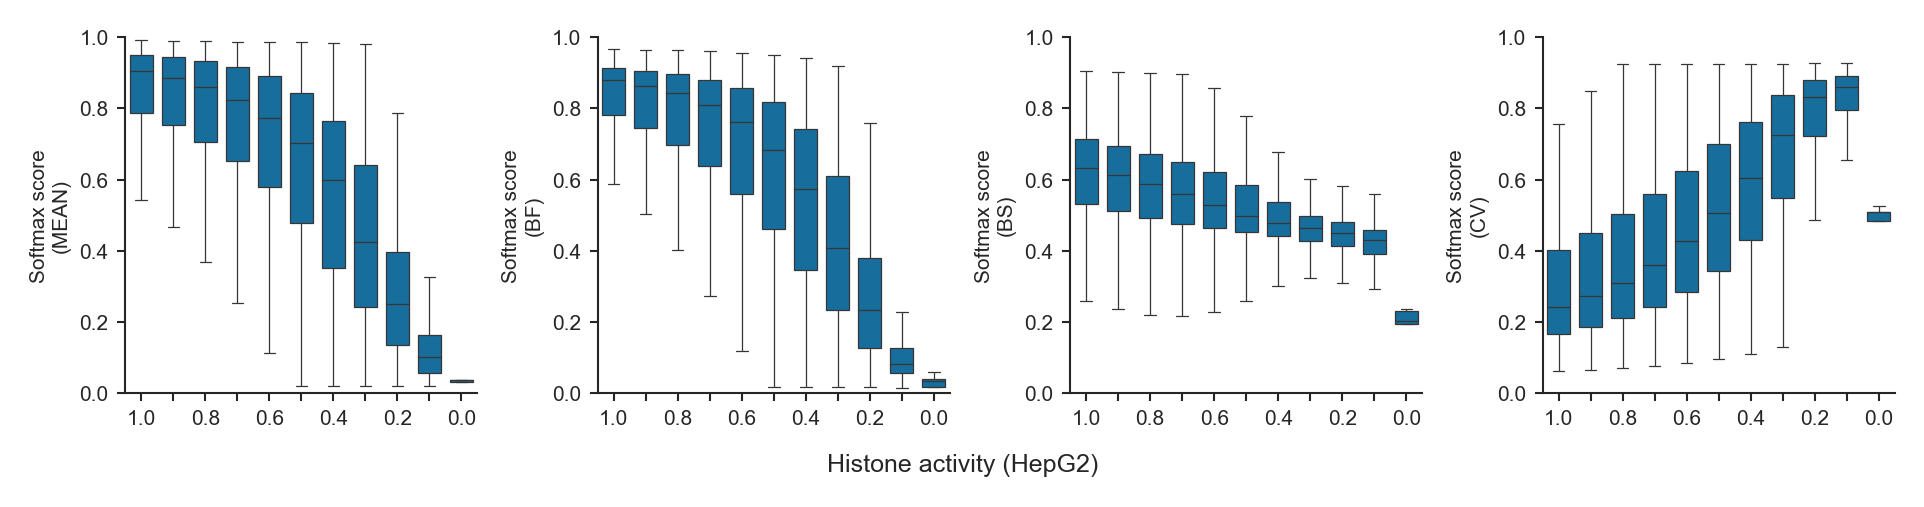

In [22]:
eid = 'E118'
label = 1
keep_mark = 'H3K9ac'

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]
# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,4,figsize=(16/2.54, 4/2.54), constrained_layout=True)
## MEAN 
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['mean_label_label'] == label)]
high_mean_gene_ids = list(data['gene_id'].unique())

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='mean_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[0]
)
# ax[0].set_title("MEAN", fontsize=6,fontweight='regular')
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[0].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[0].set_ylim(0, 1)
ax[0].set_xlabel(f"",fontsize=6)
ax[0].set_ylabel("Softmax score\n(MEAN)",fontsize=5)


## BF  
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='bf_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[1]
)

# ax[1].set_title("BF", fontsize=6,fontweight='regular')

ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[1].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[1].set_ylim(0, 1)
ax[1].set_xlabel(f"",fontsize=6)
ax[1].set_ylabel("Softmax score\n(BF)",fontsize=5)

## BS  
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='bs_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[2]
)
# ax[2].set_title("BS", fontsize=6,fontweight='regular')

ax[2].tick_params(axis='x', labelsize=6,width=0.5)
ax[2].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[2].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[2].set_ylim(0, 1)
ax[2].set_xlabel(f"",fontsize=6)
ax[2].set_ylabel("Softmax score\n(BS)",fontsize=5)

## CV 
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_cv.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]
high_mean_gene_ids = list(data['gene_id'].unique())

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='cv_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[3]
)
# ax[3].set_title("CV", fontsize=6,fontweight='regular')

ax[3].tick_params(axis='x', labelsize=6,width=0.5)
ax[3].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[3].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[3].set_ylim(0, 1)
ax[3].set_xlabel(f"",fontsize=6)
ax[3].set_ylabel("Softmax score\n(CV)",fontsize=5)

fig.supxlabel(f"Histone activity ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5C_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

# 显示图形
plt.show()

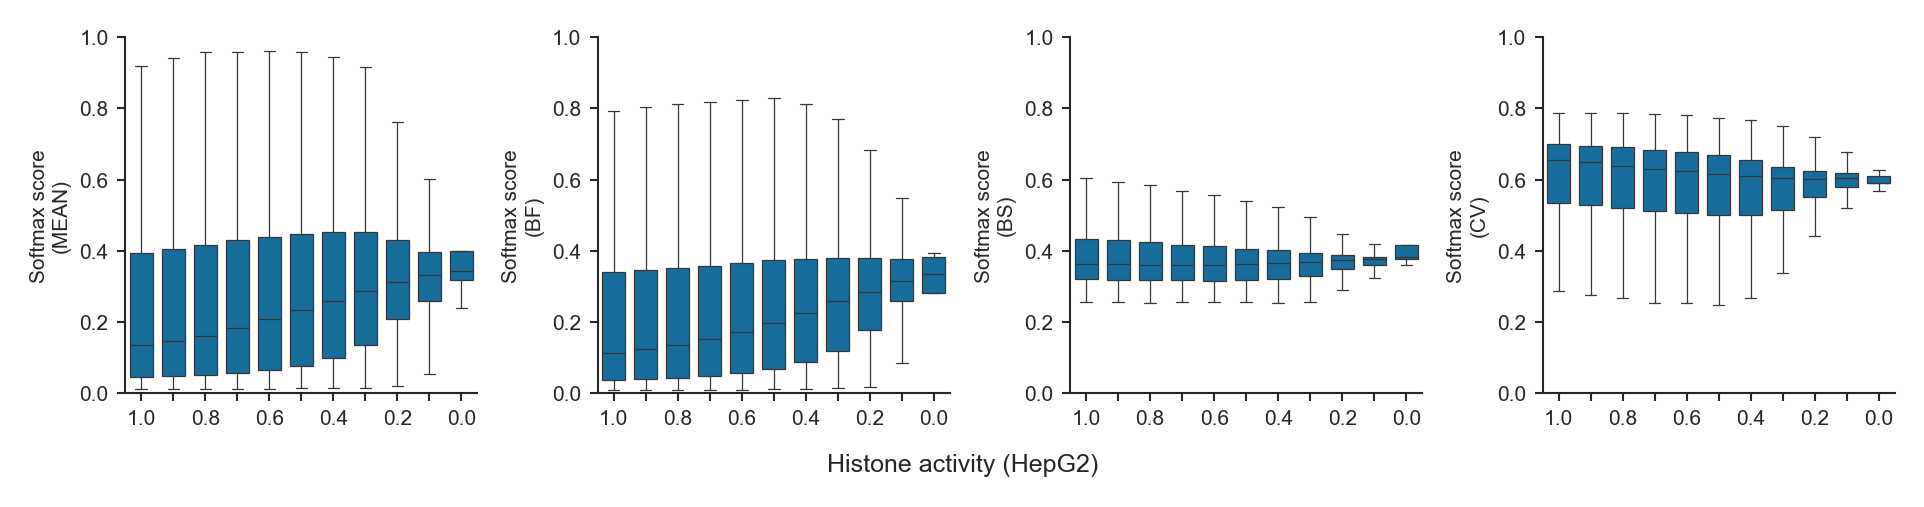

In [21]:
eid = 'E118'
label = 0
keep_mark = 'H3K27me3'

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]
# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,4,figsize=(16/2.54, 4/2.54), constrained_layout=True)
## MEAN 
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['mean_label_label'] == label)]
high_mean_gene_ids = list(data['gene_id'].unique())

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='mean_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[0]
)
# ax[0].set_title("MEAN", fontsize=6,fontweight='regular')
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[0].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[0].set_ylim(0, 1)
ax[0].set_xlabel(f"",fontsize=6)
ax[0].set_ylabel("Softmax score\n(MEAN)",fontsize=5)


## BF  
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='bf_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[1]
)

# ax[1].set_title("BF", fontsize=6,fontweight='regular')

ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[1].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[1].set_ylim(0, 1)
ax[1].set_xlabel(f"",fontsize=6)
ax[1].set_ylabel("Softmax score\n(BF)",fontsize=5)

## BS  
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='bs_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[2]
)
# ax[2].set_title("BS", fontsize=6,fontweight='regular')

ax[2].tick_params(axis='x', labelsize=6,width=0.5)
ax[2].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[2].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[2].set_ylim(0, 1)
ax[2].set_xlabel(f"",fontsize=6)
ax[2].set_ylabel("Softmax score\n(BS)",fontsize=5)

## CV 
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_cv.csv")
data = data[((data['keep_mark']==keep_mark)) & (data['gene_id'].isin(high_mean_gene_ids))]
high_mean_gene_ids = list(data['gene_id'].unique())

# 绘制 boxplot
sns.boxplot(
    data=data,
    y='cv_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax[3]
)
# ax[3].set_title("CV", fontsize=6,fontweight='regular')

ax[3].tick_params(axis='x', labelsize=6,width=0.5)
ax[3].tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax[3].set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax[3].set_ylim(0, 1)
ax[3].set_xlabel(f"",fontsize=6)
ax[3].set_ylabel("Softmax score\n(CV)",fontsize=5)

fig.supxlabel(f"Histone activity ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5D_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

# 显示图形
plt.show()

In [9]:
len(data['gene_id'].unique())

7940